<a href="https://colab.research.google.com/github/Ishany0/Handwritten-English-Characters-and-Digits/blob/main/Handwritten_English_Characters_and_Digits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Handwritten English Characters and Digits — CNN Classifier

**Abstract:** This project trains a CNN to classify handwritten digits (0–9), uppercase letters (A–Z), and lowercase letters (a–z) — 62 classes total — using the Kaggle dataset `sujaymann/handwritten-english-characters-and-digits`. Images are grayscale, resized to 64×64. The model reaches strong validation accuracy (~90%+) within ~15–20 epochs.

**Dataset:** 2,728 original training images + 13,640 augmented images (combined, shuffled, 80/20 train/val split) and 682 test images, all across 62 classes.

**Preprocessing:** Grayscale, 64×64 resize, pixel rescaling (1/255), batching (32), prefetching for speed.

**Model:** 4 Conv2D blocks (32→64→128→256 filters) each with BatchNorm + MaxPooling, followed by Flatten → Dropout(0.5) → Dense(128, ReLU) → Dropout(0.5) → Dense(62, Softmax). ~529K parameters total.

**Training:** Adam optimizer (lr=1e-3, clipnorm=1.0), sparse categorical cross-entropy loss, up to 30 epochs, with EarlyStopping, ReduceLROnPlateau, and a custom loss-based stopping callback.

**Results:** Training/validation accuracy climb from ~3% to 85–95%+, with loss dropping from ~4.2 to under 0.4. A confusion matrix shows most errors occur between visually similar characters (e.g., "e" vs "S", "6" vs "k", "A" vs "O"/"R", "7" vs "8").

**Conclusion:** A moderately deep CNN with batch norm, dropout, and data augmentation effectively handles 62-class handwritten character recognition, with remaining errors concentrated in genuinely ambiguous handwritten shapes.

In [18]:
import tensorflow as tf
import os

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sujaymann/handwritten-english-characters-and-digits")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'handwritten-english-characters-and-digits' dataset.
Path to dataset files: /kaggle/input/handwritten-english-characters-and-digits


In [4]:
for root, dirs, files in os.walk(path):
       print(root, dirs[:5], len(files))

/kaggle/input/handwritten-english-characters-and-digits ['handwritten-english-characters-and-digits', 'augmented_images'] 1
/kaggle/input/handwritten-english-characters-and-digits/handwritten-english-characters-and-digits ['combined_folder'] 0
/kaggle/input/handwritten-english-characters-and-digits/handwritten-english-characters-and-digits/combined_folder ['test', 'train'] 0
/kaggle/input/handwritten-english-characters-and-digits/handwritten-english-characters-and-digits/combined_folder/test ['n', '7', 'U_caps', 'r', '2'] 0
/kaggle/input/handwritten-english-characters-and-digits/handwritten-english-characters-and-digits/combined_folder/test/n [] 11
/kaggle/input/handwritten-english-characters-and-digits/handwritten-english-characters-and-digits/combined_folder/test/7 [] 11
/kaggle/input/handwritten-english-characters-and-digits/handwritten-english-characters-and-digits/combined_folder/test/U_caps [] 11
/kaggle/input/handwritten-english-characters-and-digits/handwritten-english-characte

In [5]:
   data_dir = path + "/handwritten-english-characters-and-digits/combined_folder"
   train_ds = tf.keras.utils.image_dataset_from_directory(
       data_dir + "/train",
       color_mode='grayscale',
       image_size=(64, 64),
       label_mode='int'
   )
   test_ds = tf.keras.utils.image_dataset_from_directory(
       data_dir + "/test",
       color_mode='grayscale',
       image_size=(64, 64),
       label_mode='int',
       shuffle=False
   )

Found 2728 files belonging to 62 classes.
Found 682 files belonging to 62 classes.


In [6]:
   import glob
   from PIL import Image
   sample = glob.glob(data_dir + "/train/a/*")[0]
   img = Image.open(sample)
   print(img.size, img.mode)

(1200, 900) RGB


In [7]:
base_dir = path + "/handwritten-english-characters-and-digits/combined_folder"
aug_dir = path + "/augmented_images/augmented_images1"

In [8]:
import matplotlib.pyplot as plt

IMG_SIZE = 64
BATCH_SIZE = 32
BUFFER_SIZE = 1000
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

train_original = tf.keras.utils.image_dataset_from_directory(
    base_dir + "/train",
    color_mode = 'grayscale',
    batch_size = BATCH_SIZE,
    image_size = (IMG_SIZE , IMG_SIZE),
    seed = SEED,
    label_mode = 'int'
)
train_augmented = tf.keras.utils.image_dataset_from_directory(
    aug_dir,
    color_mode = 'grayscale',
    batch_size = BATCH_SIZE,
    image_size = (IMG_SIZE , IMG_SIZE),
    seed = SEED,
    label_mode = 'int'
)


assert train_original.class_names == train_augmented.class_names, \
      "Class name ordering mismatch between train/ and augmented_images/ — do not concatenate until this is fixed"

train = train_original.concatenate(train_augmented)
train = train.shuffle(BUFFER_SIZE , seed = SEED , reshuffle_each_iteration=False)


num_combined_batches = tf.data.experimental.cardinality(train).numpy()
val_size_in_batches = int(num_combined_batches * 0.2)

val = train.take(val_size_in_batches)
train = train.skip(val_size_in_batches)



test = tf.keras.utils.image_dataset_from_directory(
    base_dir + "/test",
    color_mode = 'grayscale',
    batch_size = BATCH_SIZE,
    image_size = (IMG_SIZE , IMG_SIZE),
    seed = SEED,
    label_mode = 'int'
)

train = train.prefetch(buffer_size = AUTOTUNE)
val = val.prefetch(buffer_size = AUTOTUNE)
test = test.prefetch(buffer_size = AUTOTUNE)

print(f"Classes: {train_original.class_names}")
print(f"Total training batches: {tf.data.experimental.cardinality(train).numpy()}")

Found 2728 files belonging to 62 classes.
Found 13640 files belonging to 62 classes.
Found 682 files belonging to 62 classes.
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A_caps', 'B_caps', 'C_caps', 'D_caps', 'E_caps', 'F_caps', 'G_caps', 'H_caps', 'I_caps', 'J_caps', 'K_caps', 'L_caps', 'M_caps', 'N_caps', 'O_caps', 'P_caps', 'Q_caps', 'R_caps', 'S_caps', 'T_caps', 'U_caps', 'V_caps', 'W_caps', 'X_caps', 'Y_caps', 'Z_caps', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Total training batches: 411


In [9]:
'''
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.01),
    tf.keras.layers.RandomZoom(0.02),
    tf.keras.layers.RandomTranslation(0.02,0.02)
])
'''

'\ndata_augmentation = tf.keras.Sequential([\n    tf.keras.layers.RandomRotation(0.01),\n    tf.keras.layers.RandomZoom(0.02),\n    tf.keras.layers.RandomTranslation(0.02,0.02)\n])\n'

In [10]:
model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(64, 64, 1)),
    tf.keras.layers.Rescaling(1./255),

    #data_augmentation,

    tf.keras.layers.Conv2D(32,(3, 3),activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64,(3, 3),activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(128,(3, 3),activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(256,(3, 3),activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(62,activation='softmax')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 62)             │         7,998 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 528,958 (2.02 MB)

 Trainable params: 527,998 (2.01 MB)

 Non-trainable params: 960 (3.75 KB)

In [11]:

class Early_Stopping_Callback(tf.keras.callbacks.Callback):
  def on_epoch_end(self,epoch,logs=None):
    if logs['loss'] <0.2:
      print('\nLoss is low so cancelling training')
      self.model.stop_training = True




In [12]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 8, restore_best_weights = True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor = 'val_loss' , patience = 3 , factor = 0.5 , min_lr=1e-6)

In [13]:
EPOCHS = 30
LEARNING_RATE = 1e-3

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    train,
    validation_data = val,
    epochs=EPOCHS,
    callbacks=[Early_Stopping_Callback(), early_stop, reduce_lr]
)
test_loss, test_accuracy = model.evaluate(test)

print("Test Accuracy:", test_accuracy)

Epoch 1/30
411/411 ━━━━━━━━━━━━━━━━━━━━ 439s 646ms/step - accuracy: 0.0264 - loss: 4.1934 - val_accuracy: 0.0281 - val_loss: 4.1201 - learning_rate: 0.0010
Epoch 2/30
411/411 ━━━━━━━━━━━━━━━━━━━━ 382s 633ms/step - accuracy: 0.0638 - loss: 3.8295 - val_accuracy: 0.1744 - val_loss: 3.2521 - learning_rate: 0.0010
Epoch 3/30
411/411 ━━━━━━━━━━━━━━━━━━━━ 395s 655ms/step - accuracy: 0.1199 - loss: 3.3917 - val_accuracy: 0.1731 - val_loss: 3.5179 - learning_rate: 0.0010
Epoch 4/30
411/411 ━━━━━━━━━━━━━━━━━━━━ 386s 640ms/step - accuracy: 0.2069 - loss: 2.8996 - val_accuracy: 0.0917 - val_loss: 6.1514 - learning_rate: 0.0010
Epoch 5/30
411/411 ━━━━━━━━━━━━━━━━━━━━ 403s 673ms/step - accuracy: 0.3115 - loss: 2.3548 - val_accuracy: 0.5556 - val_loss: 1.6071 - learning_rate: 0.0010
Epoch 6/30
411/411 ━━━━━━━━━━━━━━━━━━━━ 389s 646ms/step - accuracy: 0.4017 - loss: 1.9873 - val_accuracy: 0.6642 - val_loss: 1.1309 - learning_rate: 0.0010
Epoch 7/30
411/411 ━━━━━━━━━━━━━━━━━━━━ 386s 639ms/step - accura

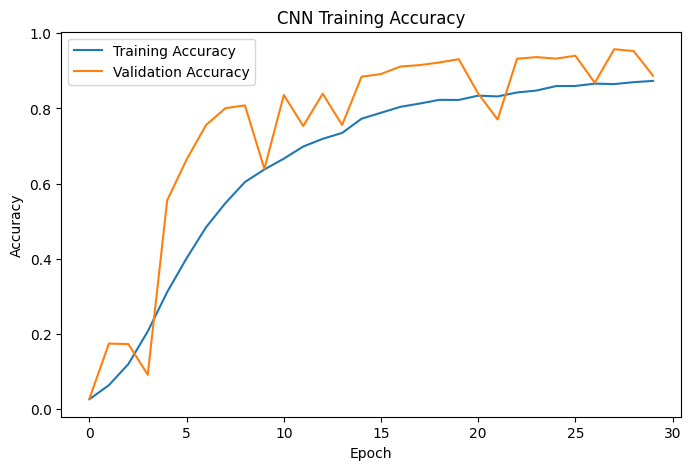

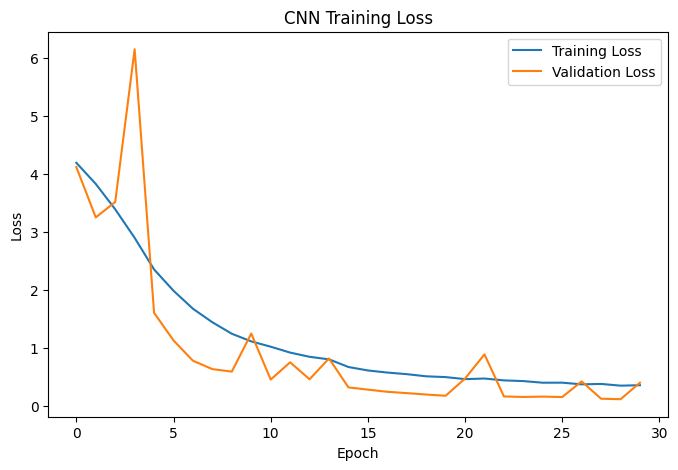

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training Accuracy")

plt.legend()
plt.show()
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training Loss")

plt.legend()
plt.show()

22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 298ms/step


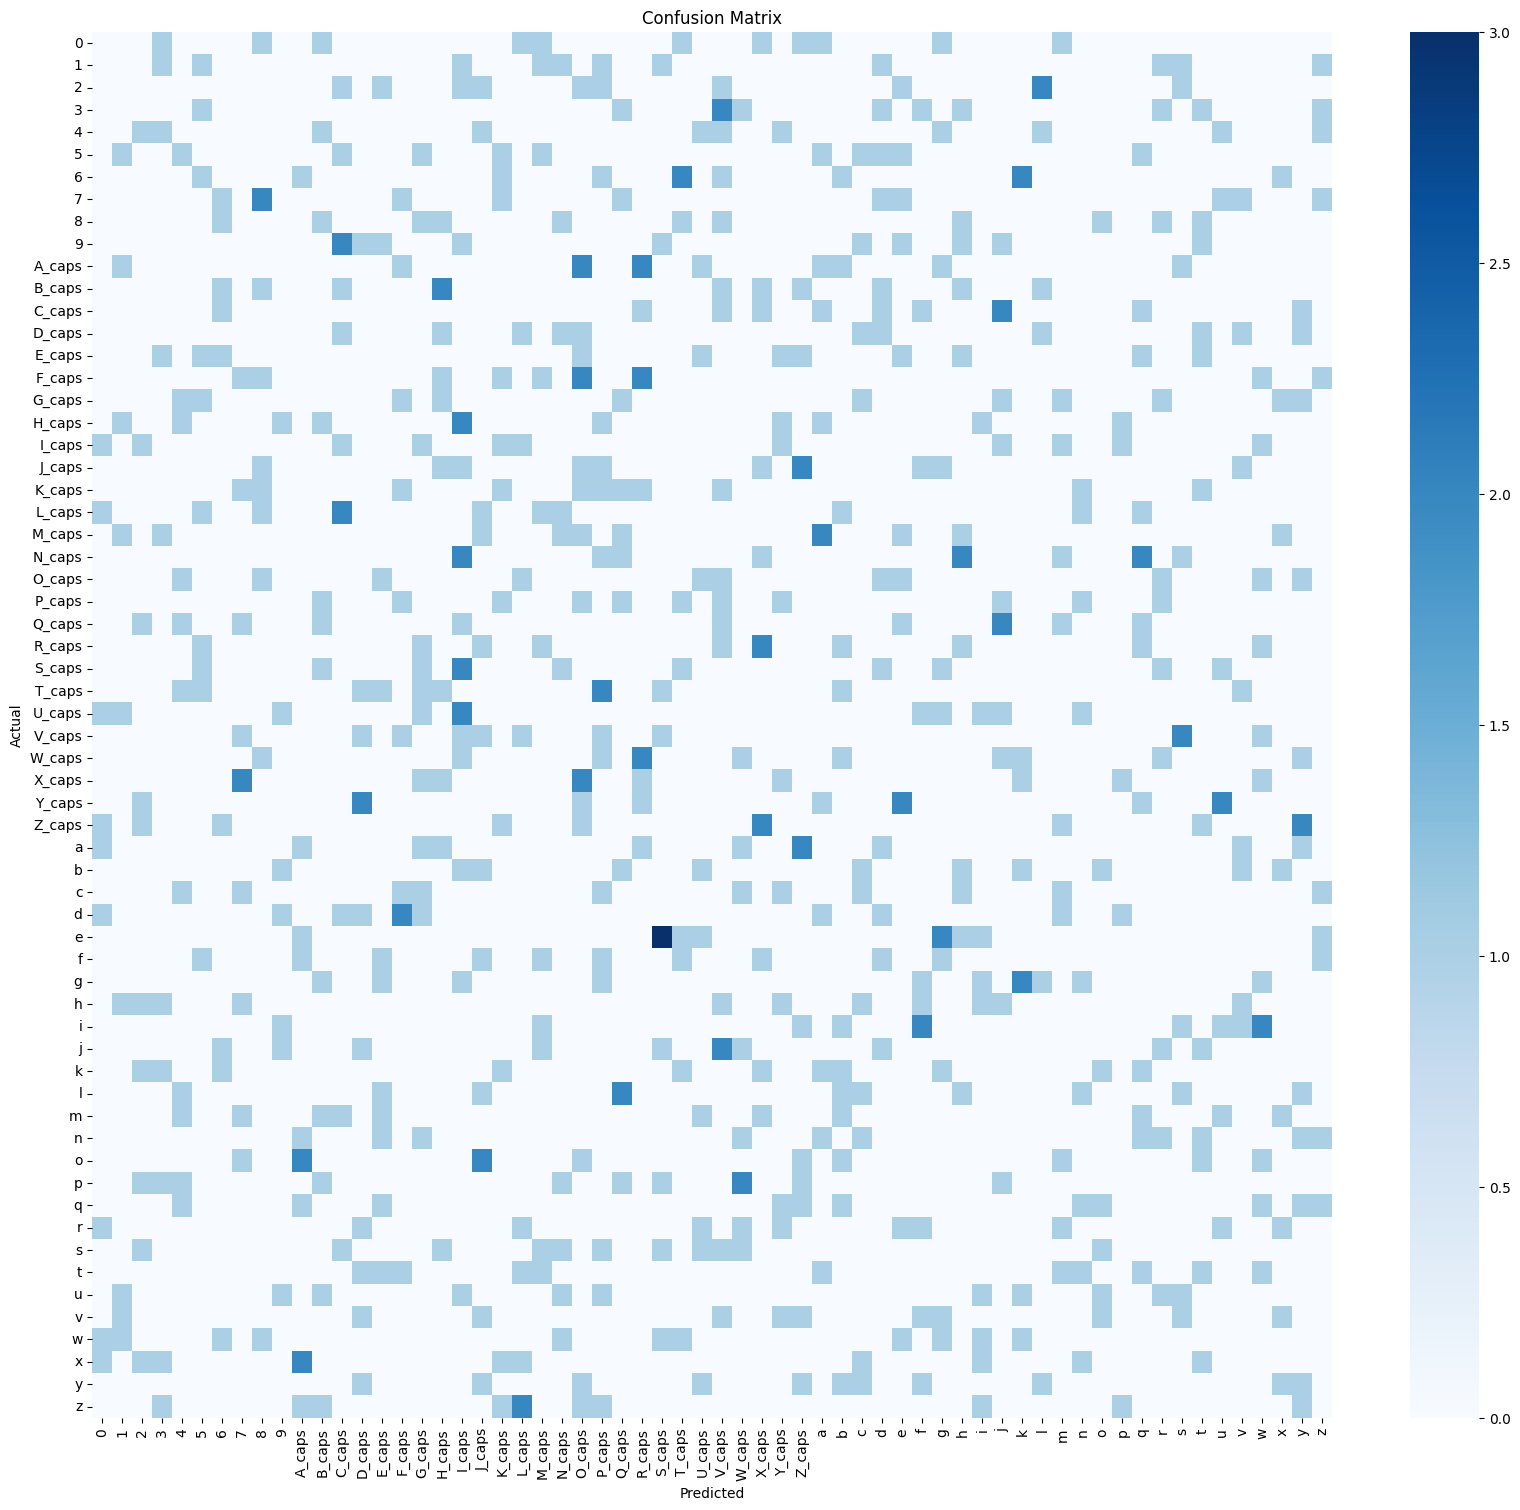

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

class_names = train_original.class_names

true_labels = []
for _, labels in test:
    true_labels.extend(labels.numpy())

predictions = model.predict(test)
predicted_labels = np.argmax(predictions, axis=1)

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(20, 18))
sns.heatmap(cm, xticklabels=class_names, yticklabels=class_names, cmap='Blues', annot=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [17]:

cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)


rows, cols = np.unravel_index(np.argsort(cm_errors, axis=None)[::-1][:15], cm_errors.shape)

print("Top confused pairs (actual → predicted, count):")
for r, c in zip(rows, cols):
    if cm_errors[r, c] > 0:
        print(f"{class_names[r]} → {class_names[c]}: {cm_errors[r, c]}")

Top confused pairs (actual → predicted, count):
e → S_caps: 3
l → Q_caps: 2
6 → k: 2
F_caps → R_caps: 2
A_caps → R_caps: 2
A_caps → O_caps: 2
i → f: 2
z → L_caps: 2
g → k: 2
Q_caps → j: 2
o → J_caps: 2
V_caps → s: 2
X_caps → O_caps: 2
N_caps → q: 2
7 → 8: 2
